## Feature Descriptions

| Feature | Description |
|---|---|
| customerID | unique customer identifier. |
| gender | customer gender. |
| SeniorCitizen | whether the customer is a senior citizen. |
| Partner | whether the customer has a partner. |
| Dependents | whether the customer has dependents. |
| tenure | number of months the customer has been using the company's services. |
| PhoneService | whether phone service is enabled. |
| MultipleLines | whether multiple phone lines are enabled. |
| InternetService | type of the customer's internet service. |
| OnlineSecurity | whether the online security service is enabled. |
| OnlineBackup | whether the online backup service is enabled. |
| DeviceProtection | whether the device protection service is enabled. |
| TechSupport | whether technical support is enabled. |
| StreamingTV | whether the streaming TV service is enabled. |
| StreamingMovies | whether the streaming movies service is enabled. |
| Contract | type of customer contract. |
| PaperlessBilling | whether the customer uses paperless billing. |
| PaymentMethod | payment method. |
| MonthlyCharges | customer's monthly charges. |
| TotalCharges | customer's total charges over the entire service period. |
| Churn | target feature: whether the customer stopped using the company's services. |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('Telco_Customer_Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.16,0.37,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.37,24.56,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.5,70.35,89.85,118.75


In [6]:
df.describe(include='object').T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [7]:
df['TotalCharges'].value_counts()

TotalCharges
          11
20.2      11
19.75      9
20.05      8
19.9       8
          ..
6849.4     1
692.35     1
130.15     1
3211.9     1
6844.5     1
Name: count, Length: 6531, dtype: int64

In [8]:
def convert_to_float(x):
    try:
        return float(x)
    
    except ValueError:
        return np.nan
    
df['TotalCharges'] = df['TotalCharges'].apply(convert_to_float)
df['TotalCharges'].value_counts()

TotalCharges
20.20      11
19.75       9
20.05       8
19.90       8
19.65       8
           ..
6849.40     1
692.35      1
130.15      1
3211.90     1
6844.50     1
Name: count, Length: 6530, dtype: int64

In [9]:
df.drop(columns=['customerID'], inplace=True)

In [10]:
df.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(22)

In [13]:
df.drop_duplicates(inplace=True, ignore_index=True)

In [14]:
# In depth check for categorical cols
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"Column: {col}")
    print(df[col].nunique())
    print(df[col].unique())
    print('-' * 80)

Column: gender
2
['Female' 'Male']
--------------------------------------------------------------------------------
Column: Partner
2
['Yes' 'No']
--------------------------------------------------------------------------------
Column: Dependents
2
['No' 'Yes']
--------------------------------------------------------------------------------
Column: PhoneService
2
['No' 'Yes']
--------------------------------------------------------------------------------
Column: MultipleLines
3
['No phone service' 'No' 'Yes']
--------------------------------------------------------------------------------
Column: InternetService
3
['DSL' 'Fiber optic' 'No']
--------------------------------------------------------------------------------
Column: OnlineSecurity
3
['No' 'Yes' 'No internet service']
--------------------------------------------------------------------------------
Column: OnlineBackup
3
['Yes' 'No' 'No internet service']
----------------------------------------------------------------------

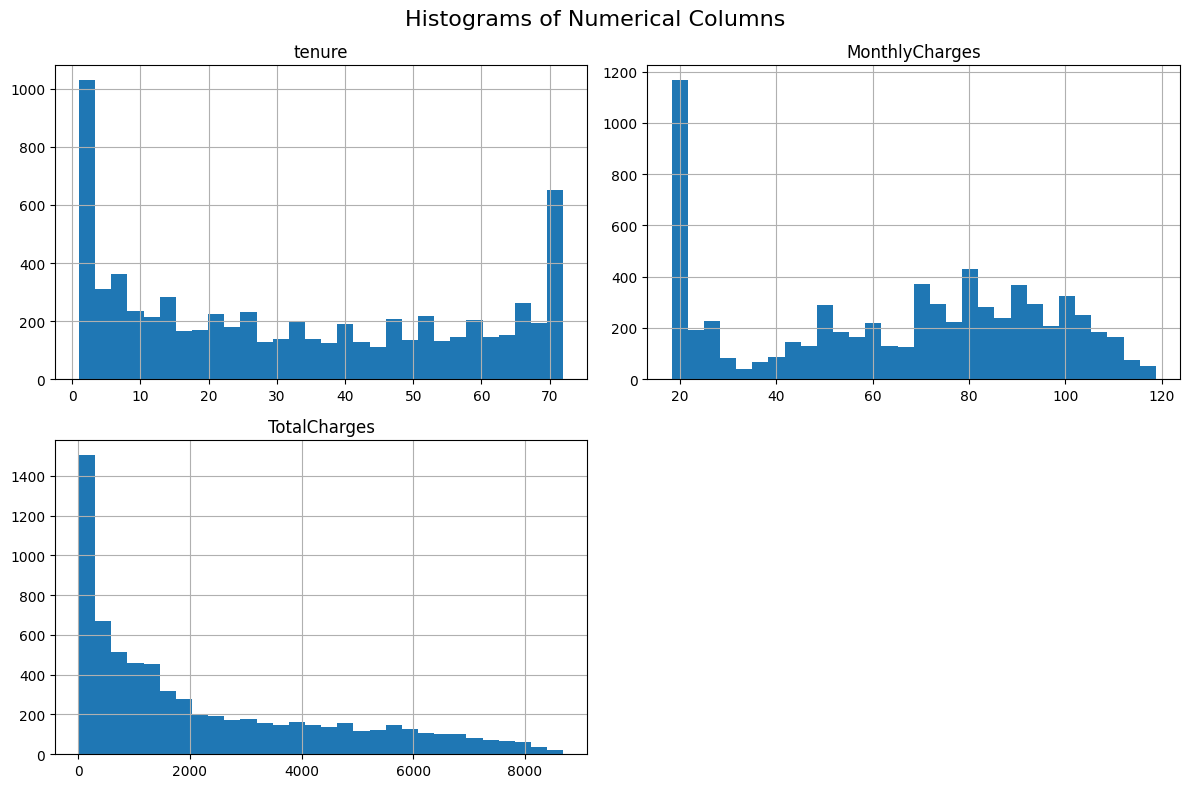

In [15]:
# In depth check for numerical cols
num_cols = df.select_dtypes(include='number').drop(columns=['SeniorCitizen'])

num_cols.hist(figsize=(12, 8), bins=30, grid=True)
plt.suptitle('Histograms of Numerical Columns', fontsize=16)
plt.tight_layout()
plt.show()

# Visualizations

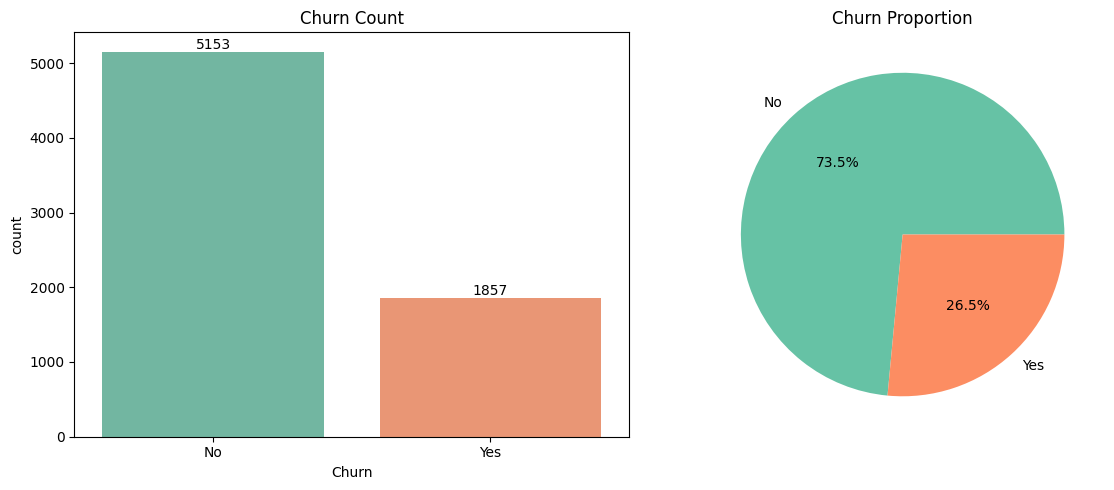

In [16]:
# Churn distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False, ax=ax[0])
ax[0].set_title('Churn Count')
for container in ax[0].containers:
    ax[0].bar_label(container)


churn_counts = df['Churn'].value_counts()
plt.pie(x=churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
ax[1].set_title('Churn Proportion')

plt.tight_layout()
plt.show()

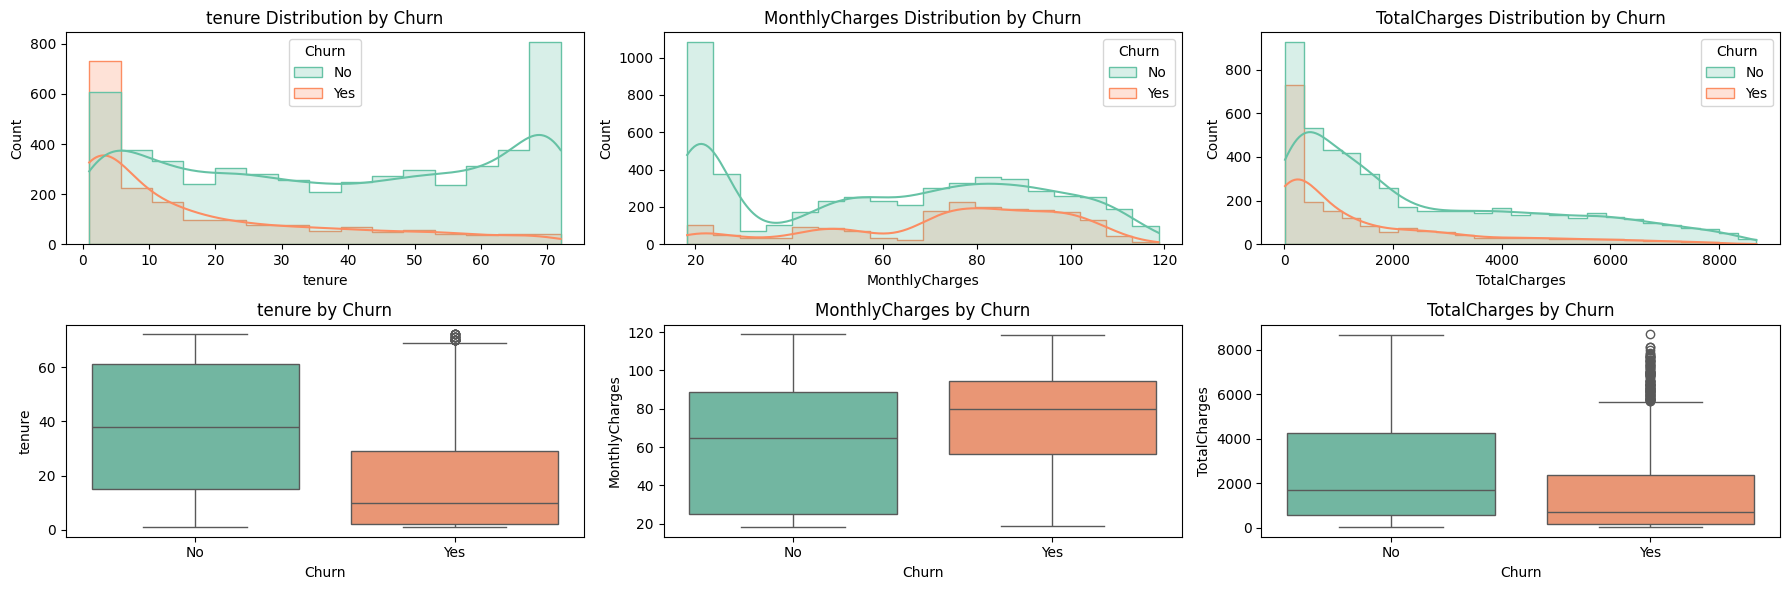

In [17]:
# Numerical features vs Churn
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(18, 6))

for i, col in enumerate(num_features):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, palette='Set2',
                 element='step', ax=axes[0, i])
    axes[0, i].set_title(f'{col} Distribution by Churn')

    sns.boxplot(data=df, x='Churn', y=col, hue='Churn', palette='Set2',
                legend=False, ax=axes[1, i])
    axes[1, i].set_title(f'{col} by Churn')

plt.tight_layout()
plt.show()

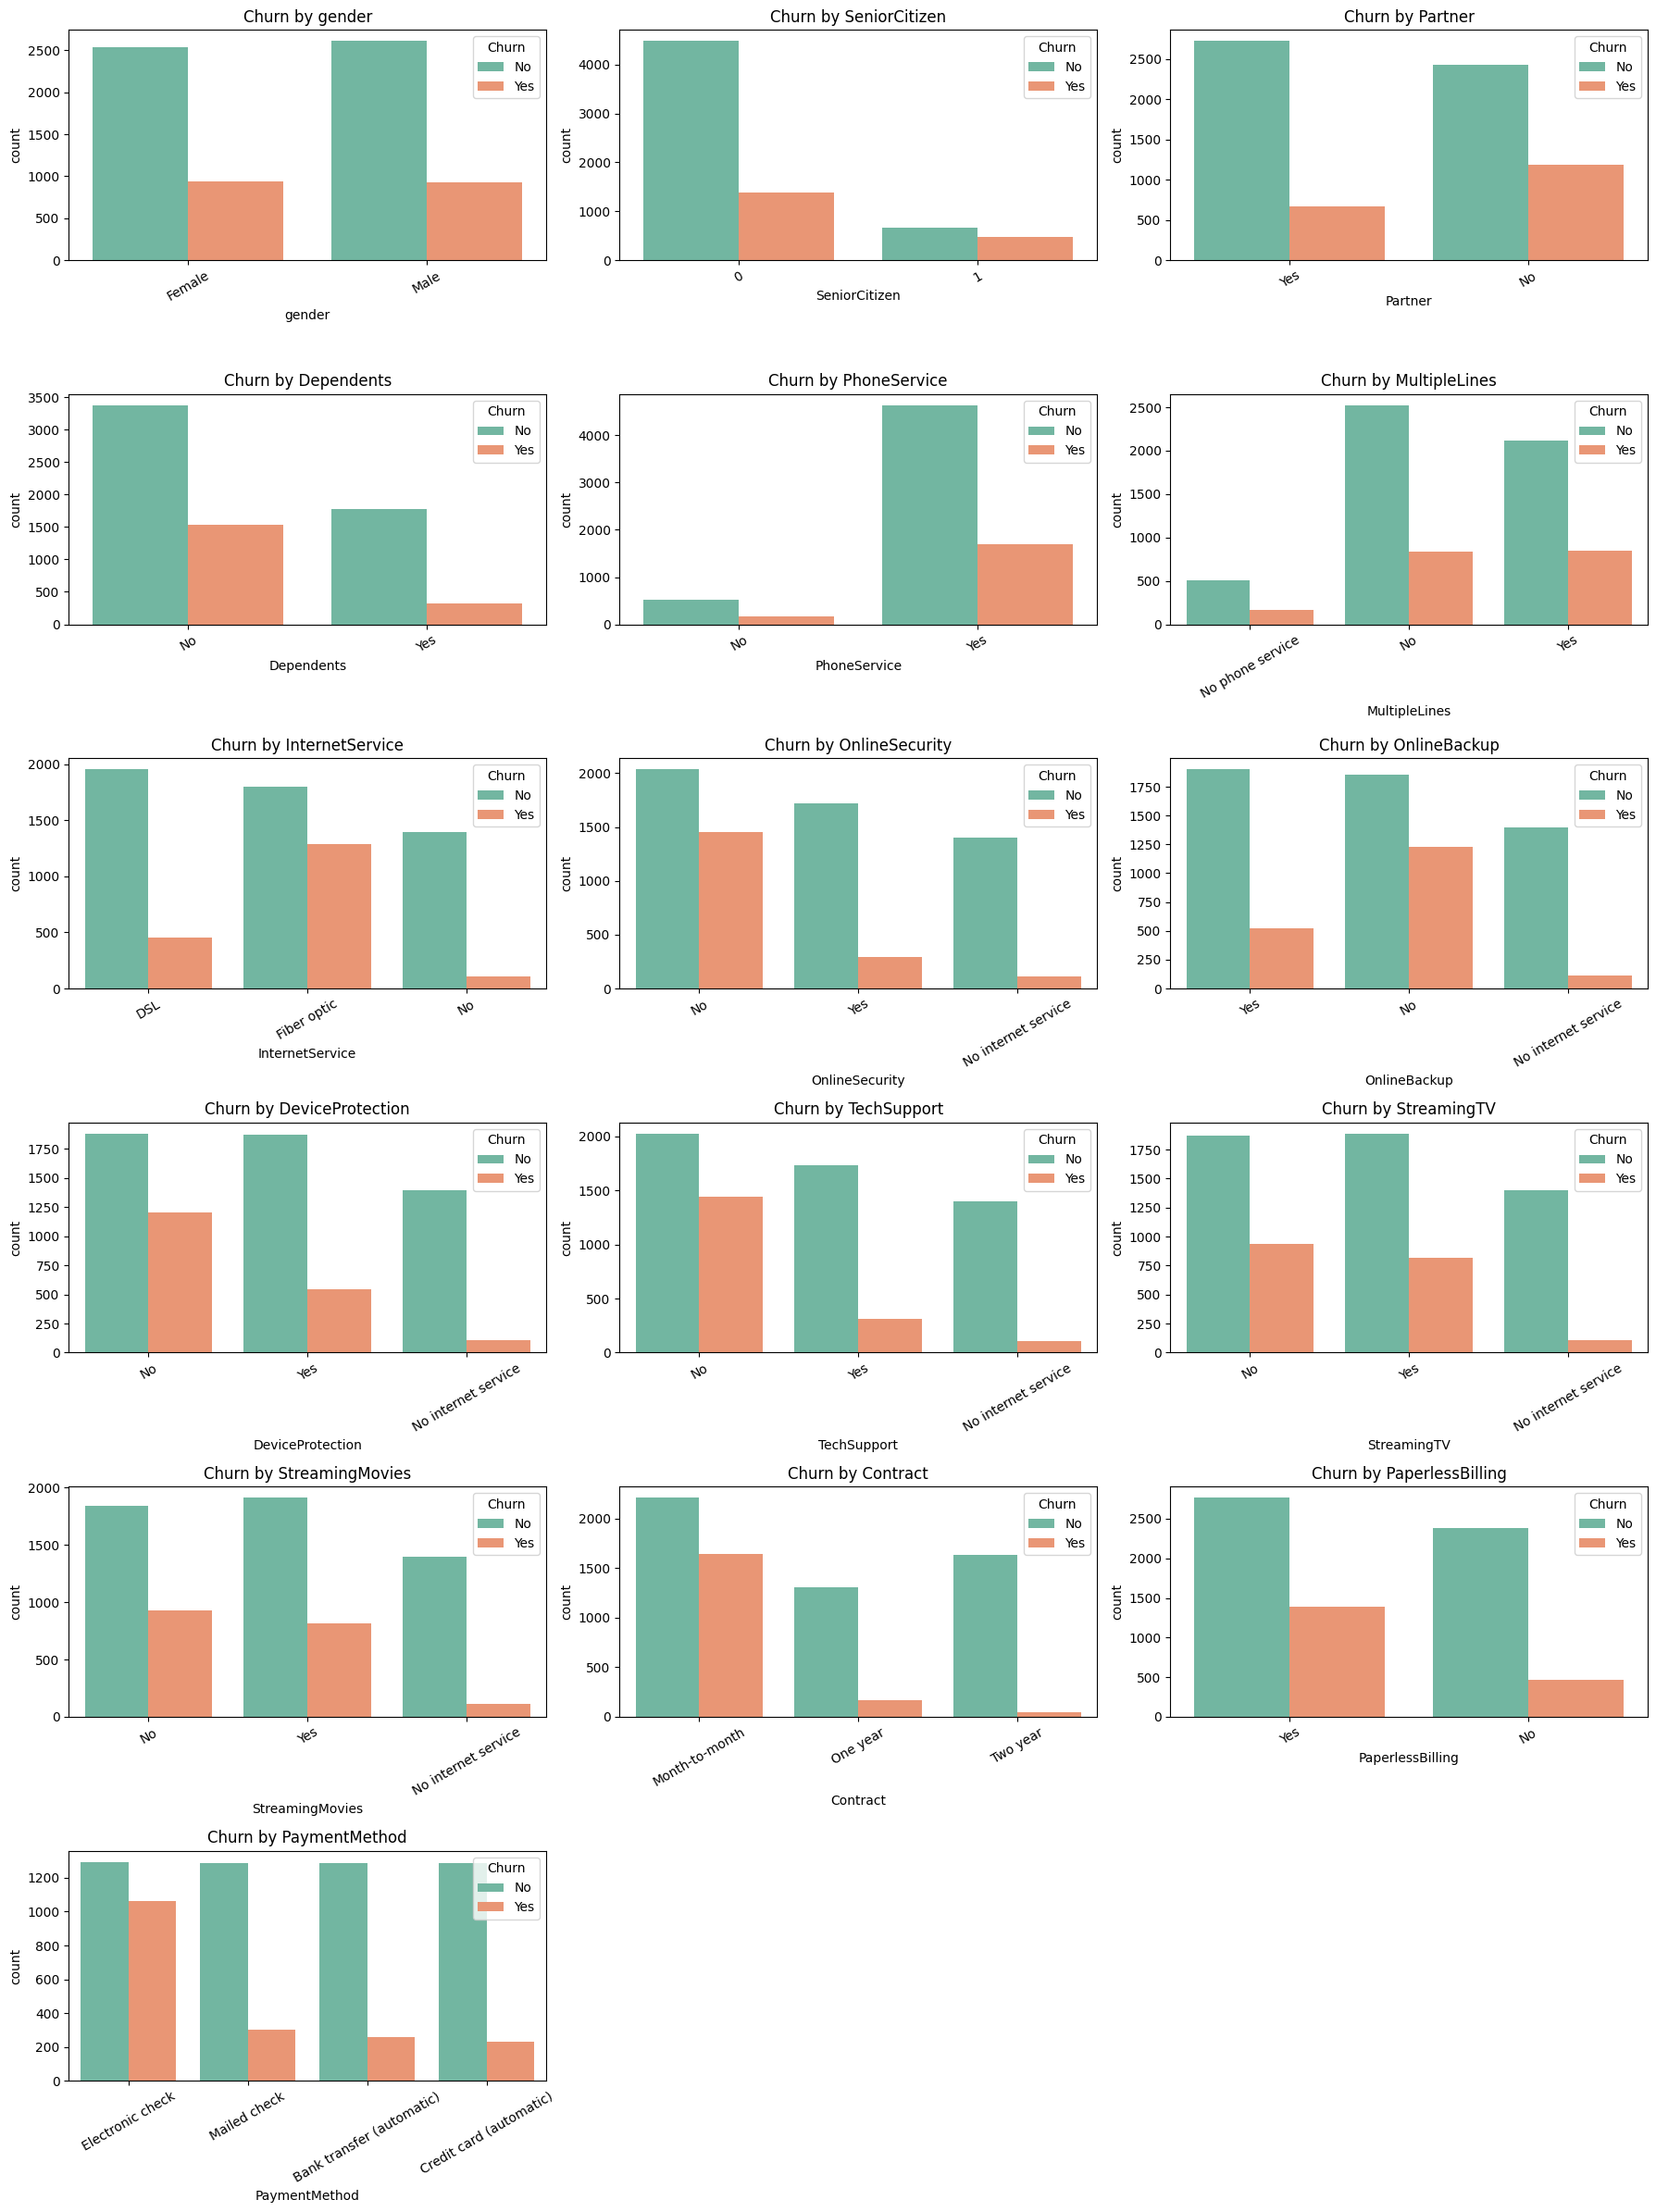

In [18]:
# Categorical features vs Churn
cat_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaperlessBilling', 'PaymentMethod']

n_cols = 3
n_rows = -(-len(cat_features) // n_cols)  # ceil division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, hue='Churn', palette='Set2', ax=axes[i])
    axes[i].set_title(f'Churn by {col}')
    axes[i].tick_params(axis='x', rotation=30)

# Hide any unused subplots
for j in range(len(cat_features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

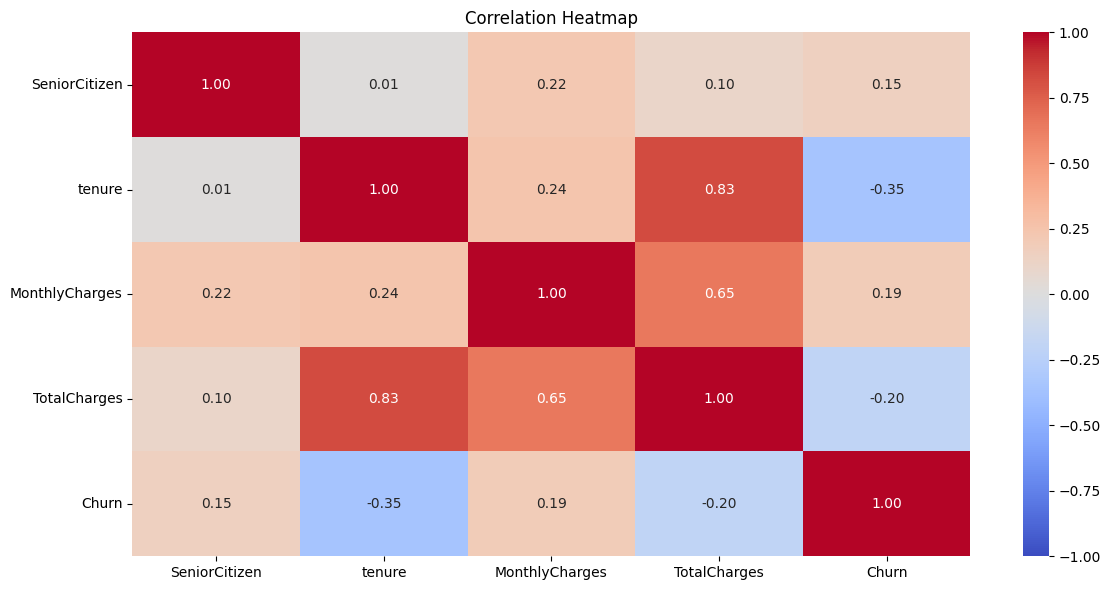

In [19]:
# Correlation heatmap
corr_df = df.select_dtypes(include='number').copy()
corr_df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

plt.figure(figsize=(12, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

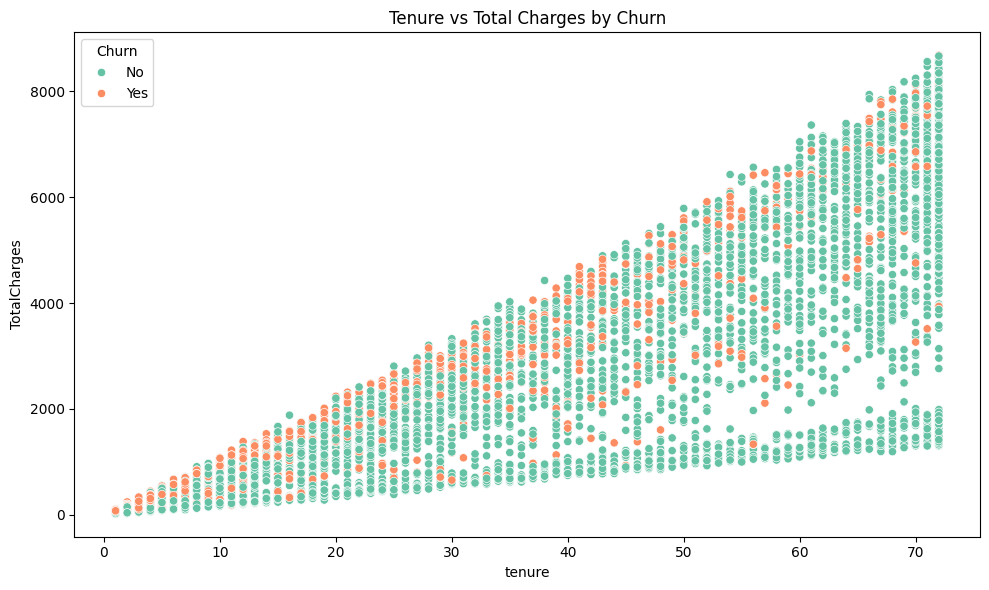

In [20]:
# tenure vs TotalCharges
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='TotalCharges', hue='Churn', palette='Set2')
plt.title('Tenure vs Total Charges by Churn')
plt.tight_layout()
plt.show()

# Preprocessing

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

# Split the data into training and testing sets
x = df.drop('Churn', axis=1)
y = df['Churn']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
# Scaling & Encoding

num_cols = x.select_dtypes(include= 'number').drop(columns=['SeniorCitizen']).columns
cat_cols = x.select_dtypes(include= 'object').columns

my_transformer = ColumnTransformer([
    ('Numerical', StandardScaler(), num_cols),
    ('Categorical', OneHotEncoder(sparse_output= False, drop= 'first'), cat_cols)
])

In [23]:
x_train = my_transformer.fit_transform(x_train)
x_test = my_transformer.transform(x_test)

In [24]:
x_train

array([[-0.67248878, -0.37019806, -0.62149265, ...,  0.        ,
         1.        ,  0.        ],
       [-1.28720372, -1.33303456, -1.00260374, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.33558   ,  1.41697332,  2.11141035, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.76184606, -1.03433831, -0.22747562, ...,  0.        ,
         0.        ,  0.        ],
       [-1.24622272, -1.4915605 , -0.99686777, ...,  0.        ,
         0.        ,  0.        ],
       [-0.79543177,  0.84461125, -0.48376318, ...,  0.        ,
         1.        ,  0.        ]], shape=(5608, 29))

In [25]:
# Target Encoding
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [26]:
y_train

array([0, 0, 0, ..., 0, 0, 1], shape=(5608,))

# Models

### Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [28]:
lr_model = LogisticRegression()
lr_model.fit(x_train, y_train)

print('Training Accuracy: ', round(lr_model.score(x_train, y_train) * 100, 2))
print('Testing Accuracy: ', round(lr_model.score(x_test, y_test) * 100, 2))

Training Accuracy:  80.47
Testing Accuracy:  81.1


In [29]:
y_train_pred = lr_model.predict(x_train)
y_test_pred = lr_model.predict(x_test)

print('Train LR :\n', classification_report(y_train, y_train_pred))
print( '-' * 60)
print('Test LR :\n', classification_report(y_test, y_test_pred))

Train LR :
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      4122
           1       0.66      0.55      0.60      1486

    accuracy                           0.80      5608
   macro avg       0.75      0.72      0.74      5608
weighted avg       0.80      0.80      0.80      5608

------------------------------------------------------------
Test LR :
               precision    recall  f1-score   support

           0       0.85      0.91      0.88      1031
           1       0.68      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.73      0.74      1402
weighted avg       0.80      0.81      0.80      1402



Train LR :


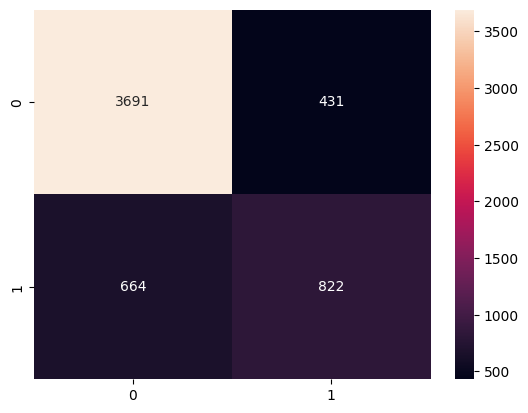

Test LR :


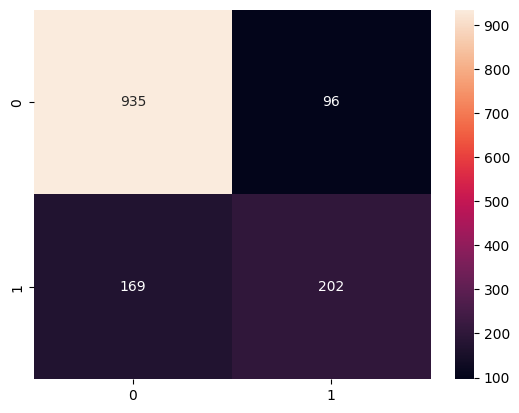

In [30]:
print('Train LR :')
sns.heatmap(confusion_matrix(y_train,y_train_pred),annot=True, fmt='g')
plt.show()

print('Test LR :')
sns.heatmap(confusion_matrix(y_test,y_test_pred),annot=True, fmt='g')
plt.show()

### SVC

In [31]:
svm_model = SVC(kernel='rbf', C=0.5)
svm_model.fit(x_train, y_train)

print('Training Accuracy: ', round(svm_model.score(x_train, y_train) * 100, 2))
print('Testing Accuracy: ', round(svm_model.score(x_test, y_test) * 100, 2))

Training Accuracy:  81.03
Testing Accuracy:  80.03


In [32]:
y_train_pred = svm_model.predict(x_train)
y_test_pred = svm_model.predict(x_test)

print('Train SVM :\n', classification_report(y_train, y_train_pred))
print( '-' * 60)
print('Test SVM :\n', classification_report(y_test, y_test_pred))

Train SVM :
               precision    recall  f1-score   support

           0       0.83      0.93      0.88      4122
           1       0.71      0.48      0.57      1486

    accuracy                           0.81      5608
   macro avg       0.77      0.71      0.73      5608
weighted avg       0.80      0.81      0.80      5608

------------------------------------------------------------
Test SVM :
               precision    recall  f1-score   support

           0       0.83      0.92      0.87      1031
           1       0.68      0.46      0.55       371

    accuracy                           0.80      1402
   macro avg       0.75      0.69      0.71      1402
weighted avg       0.79      0.80      0.79      1402



Train SVM :


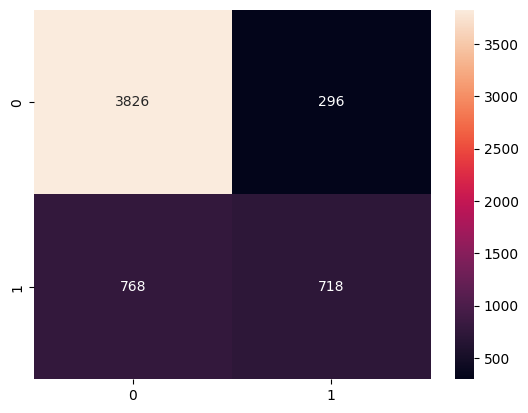

Test SVM :


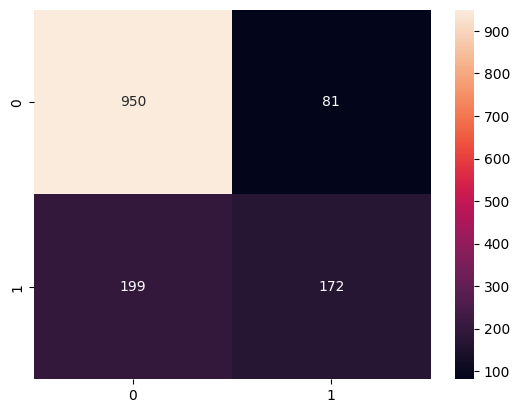

In [33]:
print('Train SVM :')
sns.heatmap(confusion_matrix(y_train,y_train_pred),annot=True, fmt='g')
plt.show()

print('Test SVM :')
sns.heatmap(confusion_matrix(y_test,y_test_pred),annot=True, fmt='g')
plt.show()